In [33]:
import rebound
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from astropy import units as u, constants as const

plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [72]:
## VALUES

# Proxima d
m1 = float(0.26 * u.earthMass/u.solMass) # mass (solar masses)
a1 = 0.029 # semi-major axis (au)
e1 = 0.3 # eccentricity
pomega1 = 0. # longitude of pericenter (rad)

# Proxima b
m2 = float(1.07 * u.earthMass/u.solMass) # mass (solar masses)
a2 = 0.049 # semi-major axis (au)
e2 = 0.2 # eccentricity
pomega2 = np.pi # longitude of pericenter (rad)

In [74]:
## PERFORM REBOUND SIMULATION

sim = rebound.Simulation()
sim.integrator = "whfast"
sim.ri_whfast.safe_mode = False
sim.add(m=0.12)                      # Proxima Centauri
sim.add(m=m1, a=a1, e=e1, inc=0., Omega=0., pomega=pomega1)  # Proxima d
sim.add(m=m2, a=a2, e=e2, inc=0., Omega=np.pi, pomega=pomega2)  # Proxima b
star = sim.particles[0]
d = sim.particles[1]
b = sim.particles[2]
sim.dt = 0.05 * d.P # timestep is 5% of Proxima d's orbital period
# sim.ri_ias15.min_dt = 1e-4 * sim.dt
sim.move_to_com()
sim.exit_max_distance = 20.
data = [[0., a1, a2, e1, e2, pomega1, pomega2]]

while sim.t <= 1e6 * b.P: # Integrate ~1 million orbits of Proxima b
    sim.steps(100)
    do = d.calculate_orbit(primary=star)
    bo = b.calculate_orbit(primary=star)
    data.append([sim.t, do.a, bo.a, do.e, bo.e, do.pomega, bo.pomega])

column_names = ['time', 'd_semi', 'b_semi', 'd_ecc', 'b_ecc', 'd_pomega', 'b_pomega']
out = pd.DataFrame(data=data, columns=column_names)

In [133]:
## THE FRAMES

def makeframe(out, idx, dpi=100, close=False):
    # Read data
    try:
        time = out['time'][idx]
        d_semi = out['d_semi'][idx]
        b_semi = out['b_semi'][idx]
        d_ecc = out['d_ecc'][idx]
        b_ecc = out['b_ecc'][idx]
        d_pomega = out['d_pomega'][idx]
        b_pomega = out['b_pomega'][idx]
    except KeyError:
        print('This simulation ended before that time index was reached!')
        return None

    # Equation of an ellipse in polar coordinates
    thetas = np.linspace(0., 2*np.pi, 1000)
    r1 = [d_semi * (1 - d_ecc**2)/(1 + d_ecc * np.cos(theta - d_pomega)) for theta in thetas]
    r2 = [b_semi * (1 - b_ecc**2)/(1 + b_ecc * np.cos(theta - b_pomega)) for theta in thetas]
    
    # Create orbit plot
    fig, ax = plt.figure(figsize=(7, 10)), plt.subplot(111, projection='polar')
    fig.patch.set_facecolor('k'); ax.set_facecolor('k')
    ax.plot(thetas, r1, c='C1', label='d')
    ax.plot(thetas, r2, c='C0', label='b')
    ax.scatter(0., 0., marker='*', s=100, c='C3')
    ax.grid(False)
#     ax.legend(loc=0)
    ax.set_title(r'\textbf{Proxima d \& b}', fontsize=18, color='w')
    ax.set_rticks([])
    ax.set_rmax(0.08);
    plt.savefig('Documents/website-gif/' + str(idx) + '.png', dpi=dpi)
    if close:
        plt.close()

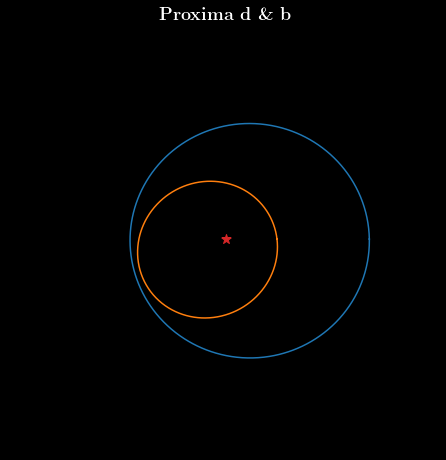

In [134]:
makeframe(out, 2000, 400)

In [135]:
final = len(out) + 1
step_size = 1000
for i in np.arange(20, final):
    if i % step_size == 0:
        print(i)
        makeframe(out, i, 400, close=True)
frames = [str(n) + '.png' for n in np.arange(20, final) if n % step_size == 0]

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
158000
15

In [136]:
with imageio.get_writer('website-orbits.gif', mode='I') as writer:
    for frame in frames:
        image = imageio.imread(os.path.join('/Users/jrlivesey/Documents/website-gif/', frame))
        print(frame)
        writer.append_data(image)

1000.png
2000.png
3000.png
4000.png
5000.png
6000.png
7000.png
8000.png
9000.png
10000.png
11000.png
12000.png
13000.png
14000.png
15000.png
16000.png
17000.png
18000.png
19000.png
20000.png
21000.png
22000.png
23000.png
24000.png
25000.png
26000.png
27000.png
28000.png
29000.png
30000.png
31000.png
32000.png
33000.png
34000.png
35000.png
36000.png
37000.png
38000.png
39000.png
40000.png
41000.png
42000.png
43000.png
44000.png
45000.png
46000.png
47000.png
48000.png
49000.png
50000.png
51000.png
52000.png
53000.png
54000.png
55000.png
56000.png
57000.png
58000.png
59000.png
60000.png
61000.png
62000.png
63000.png
64000.png
65000.png
66000.png
67000.png
68000.png
69000.png
70000.png
71000.png
72000.png
73000.png
74000.png
75000.png
76000.png
77000.png
78000.png
79000.png
80000.png
81000.png
82000.png
83000.png
84000.png
85000.png
86000.png
87000.png
88000.png
89000.png
90000.png
91000.png
92000.png
93000.png
94000.png
95000.png
96000.png
97000.png
98000.png
99000.png
100000.png
101000.p